In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. LOG DATA PROCESSING & WATER SATURATION
# ==========================================

# Given Constants
phi = 0.23  # Porosity (Pi in prompt)
a = 1.0
m = 2.0
n = 2.0

In [4]:
# Simulating log data: Depth (ft) and True Resistivity Rt (ohm-m)
# Let's assume a water zone exists at the bottom (depth 8050-8100) where Rt is low
log_data = pd.DataFrame({
    'Depth': np.arange(8000, 8110, 10),
    'Rt': [45, 48, 50, 52, 55, 42, 38, 30, 2.1, 2.0, 2.0] # Drop at 8090+ indicates water zone
})

In [7]:
# Isolate water zone to find Rw (where Sw = 1.0 -> Rw = Rt * phi^m / a)
water_zone_Rt = log_data[log_data['Depth'] >= 8090]['Rt'].mean()
Rw = (water_zone_Rt * (phi ** m)) / a

print(f"Calculated Rw from Water Zone: {Rw:.4f} ohm-m")

Calculated Rw from Water Zone: 0.1058 ohm-m


In [8]:
# Calculate Sw for the reservoir interval (Oil Zone: Depth < 8090)
oil_zone = log_data[log_data['Depth'] < 8090].copy()
oil_zone['Sw'] = ((a * Rw) / ((phi ** m) * oil_zone['Rt'])) ** (1 / n)

# Average Sw for the oil-bearing zone
avg_Sw = oil_zone['Sw'].mean()
print(f"Average Water Saturation (Sw) in Oil Zone: {avg_Sw:.4f}")

Average Water Saturation (Sw) in Oil Zone: 0.2982


In [9]:
# ==========================================
# 2. INITIAL OIL IN PLACE (OIIP) VOLUMETRIC
# ==========================================
# Formula: N = A * h * phi * (1 - Sw)
# Assuming reservoir dimensions: Area (A) and Net Pay Thickness (h)
A = 400      # acres
h = 30       # feet

In [10]:
# Volumetric OIIP in Reservoir Barrels (as requested by the formula)
N_volumetric = A * h * phi * (1 - avg_Sw)
print(f"Volumetric OIIP (N): {N_volumetric:,.2f} Reservoir Barrels\n")

Volumetric OIIP (N): 1,937.06 Reservoir Barrels



In [11]:
# ==========================================
# 3. HAVLENA-ODEH MATERIAL BALANCE PLOT
# ==========================================
# For an isolated/depletion reservoir (No water influx We=0, neglected gas cap m=0):
# F = N * (Eo + Efw)  -> Plotting F vs (Eo + Efw) yields a straight line with slope N.

# Historical Production & PVT Data
historical_data = pd.DataFrame({
    'Pressure': [4000, 3800, 3600, 3400, 3200],
    'Np': [0, 1.2e5, 2.5e5, 3.9e5, 5.3e5],       # STB
    'Gp': [0, 9.6e7, 2.2e8, 3.8e8, 5.7e8],       # SCF
    'Bo': [1.25, 1.24, 1.22, 1.20, 1.18],        # bbl/STB
    'Bg': [0.00085, 0.00092, 0.00100, 0.00115, 0.00130], # bbl/SCF
    'Rs': [650, 600, 550, 500, 450]              # SCF/STB
})

In [12]:
# Initial PVT properties at discovery pressure (4000 psi)
Boi = historical_data['Bo'].iloc[0]
Rsi = historical_data['Rs'].iloc[0]
Cw = 3e-6
Cf = 4e-6

In [13]:
# Calculate Havlena-Odeh terms: F and Eo_efw
# F = Np * [Bo + (G_p/N_p - Rs)*Bg]
historical_data['Rp'] = historical_data['Gp'] / historical_data['Np']
historical_data['Rp'] = historical_data['Rp'].fillna(0)

historical_data['F'] = historical_data['Np'] * (historical_data['Bo'] + (historical_data['Rp'] - historical_data['Rs']) * historical_data['Bg'])
historical_data['Eo'] = (historical_data['Bo'] - Boi) + (Rsi - historical_data['Rs']) * historical_data['Bg']
delta_P = historical_data['Pressure'].iloc[0] - historical_data['Pressure']
historical_data['Efw'] = Boi * ((Cw * avg_Sw + Cf) / (1 - avg_Sw)) * delta_P
historical_data['Eo_efw'] = historical_data['Eo'] + historical_data['Efw']

In [14]:
# Determine N from the slope of F vs (Eo + Efw) using linear regression (passing through origin)
# F = N * (Eo_efw) -> N = sum(F * Eo_efw) / sum(Eo_efw^2)
valid_data = historical_data[historical_data['Eo_efw'] > 0]
N_mbal = np.sum(valid_data['F'] * valid_data['Eo_efw']) / np.sum(valid_data['Eo_efw'] ** 2)

print(f"Havlena-Odeh Validated OIIP (N): {N_mbal:,.2f} STB")

Havlena-Odeh Validated OIIP (N): 5,327,071.02 STB


In [15]:
# ==========================================
# 4. RESERVOIR PERFORMANCE PREDICTION (TARNER'S METHOD)
# ==========================================
# Predicting performance for the next pressure step (from 3200 psi to 3000 psi)
# Requires balancing the Material Balance Equation and the Instantaneous GOR equation.

# PVT data at 3000 psi
Bo_next = 1.16
Bg_next = 0.00145
Rs_next = 400
krg_kro_model = lambda sg: 0.001 * np.exp(10 * sg) # Simulated Relative Permeability ratio

In [16]:
# Known values at current step (3200 psi)
Np_current = historical_data['Np'].iloc[-1]
Gp_current = historical_data['Gp'].iloc[-1]

In [19]:
# Tarner's Iteration Loop to find the correct incremental delta_Np
# We guess delta_Np, calculate mid-point saturations, look up GOR, and check if MBE matches.
found = False
for guestimate_dNp in np.linspace(1000, 200000, 5000):
    Np_predicted = Np_current + guestimate_dNp
    
    # Calculate average gas saturation during the step to evaluate GOR
    # Tarner uses mid-point saturation values
    Np_mid = Np_current + (guestimate_dNp / 2)
    Sg_mid = (1 - avg_Sw) * (1 - (Np_mid / N_mbal) * (Bo_next / Boi)) # Simplified gas saturation
    
    # GOR from Relative Permeability
    kg_ko = krg_kro_model(max(0, Sg_mid))
    mu_o_mu_g = 18.0 # Assumed viscosity ratio
    Instantaneous_R = Rs_next + (kg_ko * mu_o_mu_g * (Bo_next / Bg_next))
    
    # Total Gas produced during step
    delta_Gp = guestimate_dNp * Instantaneous_R
    Gp_predicted = Gp_current + delta_Gp
    
    # Material Balance check for N_mbal
    Rp_predicted = Gp_predicted / Np_predicted
    F_calc = Np_predicted * (Bo_next + (Rp_predicted - Rs_next) * Bg_next)
    Eo_calc = (Bo_next - Boi) + (Rsi - Rs_next) * Bg_next
    Efw_calc = Boi * ((Cw * avg_Sw + Cf) / (1 - avg_Sw)) * (historical_data['Pressure'].iloc[0] - 3000)
    
    N_calculated = F_calc / (Eo_calc + Efw_calc)
    
    # Error threshold tolerance
    if abs(N_calculated - N_mbal) / N_mbal < 0.005:
        print(f"Tarner's Method Converged for Pressure Step 3000 psi:")
        print(f" -> Predicted Incremental Oil (delta_Np): {guestimate_dNp:,.2f} STB")
        print(f" -> Total Cumulative Oil (Np): {Np_predicted:,.2f} STB")
        found = True
        break
if not found:
    print("Tarner's method loop finished. Refine the guess ranges or relative permeability curves.")

Tarner's Method Converged for Pressure Step 3000 psi:
 -> Predicted Incremental Oil (delta_Np): 27,114.02 STB
 -> Total Cumulative Oil (Np): 557,114.02 STB


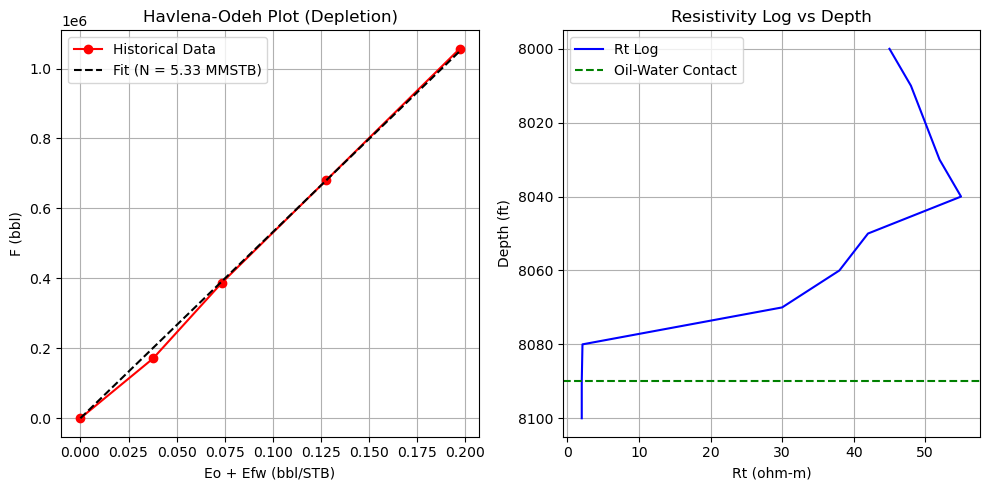

In [20]:
# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 5))

# Havlena-Odeh Plot
plt.subplot(1, 2, 1)
plt.plot(historical_data['Eo_efw'], historical_data['F'], 'ro-', label='Historical Data')
x_fit = np.linspace(0, historical_data['Eo_efw'].max(), 100)
plt.plot(x_fit, N_mbal * x_fit, 'k--', label=f'Fit (N = {N_mbal/1e6:.2f} MMSTB)')
plt.title('Havlena-Odeh Plot (Depletion)')
plt.xlabel('Eo + Efw (bbl/STB)')
plt.ylabel('F (bbl)')
plt.grid(True)
plt.legend()

# Saturation Log profile
plt.subplot(1, 2, 2)
plt.plot(log_data['Rt'], log_data['Depth'], 'b-', label='Rt Log')
plt.axhline(y=8090, color='g', linestyle='--', label='Oil-Water Contact')
plt.gca().invert_yaxis()
plt.title('Resistivity Log vs Depth')
plt.xlabel('Rt (ohm-m)')
plt.ylabel('Depth (ft)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()